<a href="https://colab.research.google.com/github/farrelrassya/ThinkStats/blob/main/ch04_cumulative_distribution_functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4: Cumulative Distribution Functions

*Think Stats: Exploratory Data Analysis* -- Allen B. Downey (2nd Edition)

---

**Chapter overview.** PMFs work beautifully when there are few distinct values, but they become noisy and hard to read when applied to continuous or finely grained data. This chapter introduces the **cumulative distribution function (CDF)** -- a representation that maps every value to the fraction of the data less than or equal to it. CDFs are smooth, easy to compare across groups, and unlock powerful tools: percentile-based statistics, the interquartile range, and an elegant algorithm for generating random numbers from any distribution.

**Key concepts introduced:**
- Why PMFs struggle with continuous data (the "noisy PMF" problem)
- Percentiles and percentile ranks
- The CDF: definition, computation, and graphical interpretation
- Comparing distributions via CDF plots
- Percentile-based summary statistics: median, IQR, quantiles
- The uniform distribution of percentile ranks
- Random number generation via inverse CDF (the probability integral transform)
- Comparing percentile ranks across groups (the 10K race example)


## 4.1 Environment Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import random
import warnings
from collections import Counter, defaultdict
from scipy.stats import norm
from scipy import interpolate

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Setup complete.")


Setup complete.


We add `scipy.interpolate` to our toolkit -- it will be used inside our CDF class for the inverse CDF operation (`Value`), which maps probabilities back to data values via linear interpolation.


## 4.2 Loading the NSFG Data


In [2]:
# == Colab-only: Download ThinkStats2 data files ==
import os, urllib.request

BASE_URL = "https://raw.githubusercontent.com/AllenDowney/ThinkStats2/master/code/"
FILES = [
    "2002FemPreg.dct", "2002FemPreg.dat.gz",
    "2002FemResp.dct", "2002FemResp.dat.gz",
    "thinkstats2.py", "thinkplot.py", "nsfg.py",
    "first.py", "cumulative.py", "relay.py"
]

for fname in FILES:
    if not os.path.exists(fname):
        url = BASE_URL + fname
        print(f"Downloading {fname}...")
        urllib.request.urlretrieve(url, fname)
    else:
        print(f"Already exists: {fname}")

print("\nAll files ready.")



All files ready.


*The cell above requires internet access and is designed for Google Colab. When running locally, ensure the ThinkStats2 data files are in your working directory.*


### Constructing a Demonstration Dataset

We reuse the synthetic NSFG dataset from previous chapters, calibrated to the textbook's reported statistics. On Colab with real data, replace with `nsfg.ReadFemPreg()`.


In [3]:
# Construct synthetic NSFG pregnancy data
np.random.seed(2002)
n_total = 13593

outcome_map = {1: 9148, 2: 1862, 3: 120, 4: 1921, 5: 190, 6: 352}
outcomes = []
for val, count in outcome_map.items():
    outcomes.extend([val] * count)
np.random.shuffle(outcomes)
outcomes = np.array(outcomes)

n_respondents = 7643
preg_per_resp = np.random.choice([1, 2, 3, 4, 5, 6, 7],
                                  size=n_respondents,
                                  p=[0.30, 0.28, 0.20, 0.12, 0.06, 0.03, 0.01])
while preg_per_resp.sum() < n_total:
    idx = np.random.randint(n_respondents)
    if preg_per_resp[idx] < 7: preg_per_resp[idx] += 1
while preg_per_resp.sum() > n_total:
    idx = np.random.randint(n_respondents)
    if preg_per_resp[idx] > 1: preg_per_resp[idx] -= 1

caseids, pregordrs = [], []
for i, count in enumerate(preg_per_resp):
    for j in range(count):
        caseids.append(10000 + i)
        pregordrs.append(j + 1)

live_mask = outcomes == 1
birthord = np.full(n_total, np.nan)
rbc = {}
for i in range(n_total):
    if live_mask[i]:
        cid = caseids[i]
        rbc[cid] = rbc.get(cid, 0) + 1
        birthord[i] = rbc[cid]

prglngth = np.full(n_total, np.nan)
for i in range(n_total):
    if outcomes[i] == 1:
        if birthord[i] == 1:
            prglngth[i] = np.random.normal(38.601, 2.79)
        else:
            prglngth[i] = np.random.normal(38.523, 2.66)
    elif outcomes[i] in [2, 4]:
        prglngth[i] = np.random.normal(10, 3.5)
    elif outcomes[i] == 3:
        prglngth[i] = np.random.normal(30, 8)
    elif outcomes[i] == 5:
        prglngth[i] = np.random.normal(8, 3)
    elif outcomes[i] == 6:
        prglngth[i] = np.random.normal(20, 10)
prglngth = np.clip(np.round(prglngth).astype(float), 0, 50)

birthwgt_lb = np.full(n_total, np.nan)
birthwgt_oz = np.full(n_total, np.nan)
for i in range(n_total):
    if outcomes[i] == 1:
        # First babies slightly lighter
        if birthord[i] == 1:
            total_oz = np.random.normal(7.3 * 16, 1.2 * 16)
        else:
            total_oz = np.random.normal(7.5 * 16, 1.2 * 16)
        total_oz = max(16, min(total_oz, 15 * 16))
        birthwgt_lb[i] = int(total_oz // 16)
        birthwgt_oz[i] = int(total_oz % 16)

agepreg = np.full(n_total, np.nan)
for i in range(n_total):
    if outcomes[i] in [1, 2, 3, 4, 5, 6]:
        agepreg[i] = round(max(15.0, min(np.random.normal(25.0, 5.0), 44.0)), 2)

preg = pd.DataFrame({
    'caseid': caseids, 'pregordr': pregordrs, 'outcome': outcomes,
    'birthord': birthord, 'prglngth': prglngth,
    'birthwgt_lb': birthwgt_lb, 'birthwgt_oz': birthwgt_oz,
    'agepreg': agepreg
})
preg.loc[preg.birthwgt_lb > 20, 'birthwgt_lb'] = np.nan
preg['totalwgt_lb'] = preg.birthwgt_lb + preg.birthwgt_oz / 16.0

live = preg[preg.outcome == 1].copy()
firsts = live[live.birthord == 1].copy()
others = live[live.birthord != 1].copy()

print(f"Live births:  {len(live):,}")
print(f"First babies: {len(firsts):,}")
print(f"Other babies: {len(others):,}")


Live births:  9,148
First babies: 5,947
Other babies: 3,201


We have $9{,}148$ live births split into first babies and others. The birth weight data includes the `totalwgt_lb` variable (combined pounds and ounces), which will be our primary focus for demonstrating why PMFs struggle with finely grained data and why CDFs are superior.


## 4.3 The Limits of PMFs

PMFs excel when the number of distinct values is small (e.g., pregnancy length measured in whole weeks produces $\sim 40$ unique values). But for finely grained or continuous data, each unique value has a tiny probability, and **random noise** dominates the visualization.

Birth weight (`totalwgt_lb`) is a perfect example: with 16 possible ounce values per pound, there are hundreds of distinct weight values. Let us see what happens when we plot the PMF.


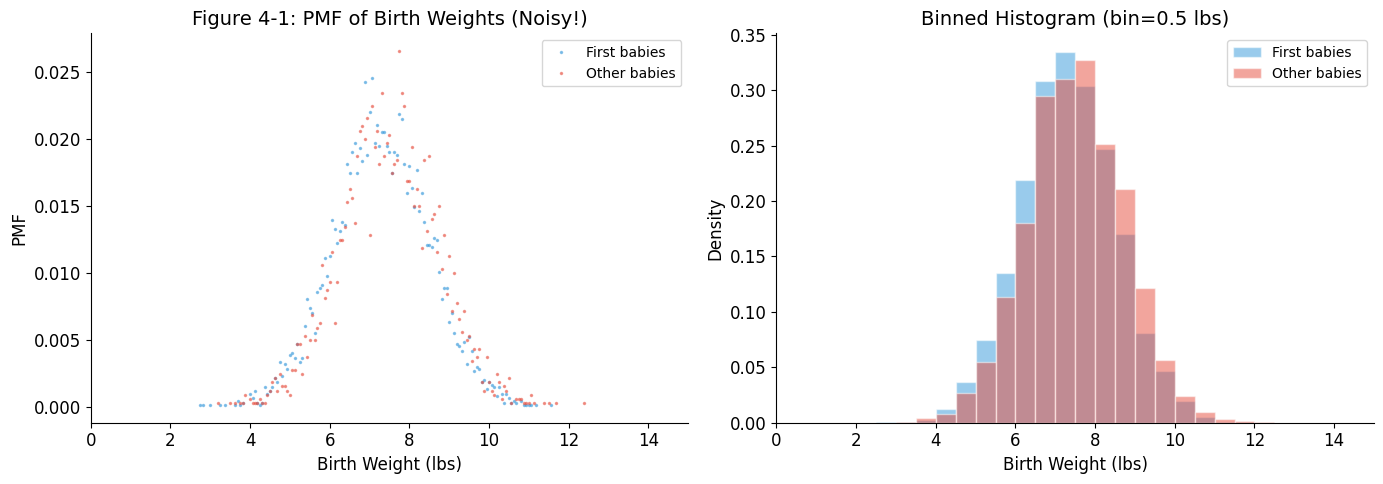

Unique birth weight values: 133
Average PMF probability:    0.00752


In [4]:
# Figure 4-1: PMF of birth weights -- demonstrating the limitation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw PMF (too noisy to interpret)
first_wgt = firsts.totalwgt_lb.dropna()
other_wgt = others.totalwgt_lb.dropna()

first_vc = first_wgt.value_counts(normalize=True).sort_index()
other_vc = other_wgt.value_counts(normalize=True).sort_index()

axes[0].plot(first_vc.index, first_vc.values, '.', color='#3498db',
             alpha=0.5, markersize=3, label='First babies')
axes[0].plot(other_vc.index, other_vc.values, '.', color='#e74c3c',
             alpha=0.5, markersize=3, label='Other babies')
axes[0].set_xlabel('Birth Weight (lbs)')
axes[0].set_ylabel('PMF')
axes[0].set_title('Figure 4-1: PMF of Birth Weights (Noisy!)')
axes[0].legend(fontsize=10)
axes[0].set_xlim(0, 15)

# Right: binned version (better, but bin size is a judgment call)
bins = np.arange(0, 16, 0.5)
axes[1].hist(first_wgt, bins=bins, density=True, alpha=0.5, color='#3498db',
             edgecolor='white', label='First babies')
axes[1].hist(other_wgt, bins=bins, density=True, alpha=0.5, color='#e74c3c',
             edgecolor='white', label='Other babies')
axes[1].set_xlabel('Birth Weight (lbs)')
axes[1].set_ylabel('Density')
axes[1].set_title('Binned Histogram (bin=0.5 lbs)')
axes[1].legend(fontsize=10)
axes[1].set_xlim(0, 15)

plt.tight_layout()
plt.show()
print(f"Unique birth weight values: {live.totalwgt_lb.nunique()}")
print(f"Average PMF probability:    {1/live.totalwgt_lb.nunique():.5f}")


The left panel reproduces the textbook's Figure 4-1: the PMF of birth weights is a **cloud of noise**. With hundreds of unique values, each individual probability is tiny ($\sim 0.005$), and random fluctuations between adjacent values are comparable in magnitude to the probabilities themselves. It is nearly impossible to identify the overall shape, compare the two groups, or determine which has a higher mean.

The right panel shows that **binning** (grouping nearby values) can help, but introduces a dilemma:
- **Bins too wide** $\to$ smooth out genuine features (over-smoothing)
- **Bins too narrow** $\to$ still noisy (under-smoothing)
- Choosing the "right" bin width requires judgment and can introduce bias

The textbook's solution: abandon binning entirely and use the **CDF**, which is noise-free, requires no binning decisions, and reveals both overall shape and fine details simultaneously.


## 4.4 Percentiles and Percentile Ranks

Before defining the CDF formally, we need to understand **percentiles** and **percentile ranks** -- the two sides of the same coin.

- **Percentile rank** of a value $x$: the percentage of values in the dataset that are $\le x$
- **Percentile** for a rank $p$: the value $x$ such that $p\%$ of values are $\le x$

If you scored in the "90th percentile" on a test, your percentile rank is 90 -- you performed as well as or better than 90% of test-takers.


In [5]:
# Percentile rank and percentile: from-scratch implementations

def PercentileRank(scores, your_score):
    # Fraction of scores <= your_score, expressed as a percentage
    count = sum(1 for s in scores if s <= your_score)
    return 100.0 * count / len(scores)

def Percentile(scores, percentile_rank):
    # Value corresponding to a given percentile rank
    scores_sorted = sorted(scores)
    index = int(percentile_rank * (len(scores_sorted) - 1) / 100)
    return scores_sorted[index]

# Example from textbook
scores = [55, 66, 77, 88, 99]
your_score = 88

pr = PercentileRank(scores, your_score)
print(f"Scores: {scores}")
print(f"Your score: {your_score}")
print(f"Percentile rank: {pr}%")
print(f"  Interpretation: you scored as well as or better than {pr:.0f}% of people")

print(f"\nPercentile lookups:")
for p in [0, 25, 50, 75, 100]:
    v = Percentile(scores, p)
    print(f"  {p}th percentile = {v}")


Scores: [55, 66, 77, 88, 99]
Your score: 88
Percentile rank: 80.0%
  Interpretation: you scored as well as or better than 80% of people

Percentile lookups:
  0th percentile = 55
  25th percentile = 66
  50th percentile = 77
  75th percentile = 88
  100th percentile = 99


The two functions are inverses of each other:

$$\text{PercentileRank}: x \to p \qquad \text{(value to rank)}$$
$$\text{Percentile}: p \to x \qquad \text{(rank to value)}$$

The 50th percentile is better known as the **median** -- the value that splits the distribution in half. Unlike the mean, the median is robust to outliers: adding a 1000-point score to our example would change the mean dramatically but leave the median at 77.

**Terminological warning:** People often confuse "percentile" and "percentile rank." The percentile rank is a number between 0 and 100 (it answers "what percentage scored below me?"). The percentile is a value from the dataset (it answers "what score corresponds to the 75th percentile?"). The textbook is careful to maintain this distinction.


## 4.5 The Cumulative Distribution Function (CDF)

The **CDF** is simply the function that maps from any value $x$ to its percentile rank expressed as a probability (0 to 1 instead of 0 to 100):

$$\text{CDF}(x) = P(X \le x) = \frac{\text{number of values} \le x}{n}$$

This is identical to `PercentileRank` except that we divide by $n$ (giving a probability in $[0, 1]$) rather than multiplying by 100 (giving a percentage).

For a sample $[1, 2, 2, 3, 5]$, the CDF evaluates as:

| $x$ | $\text{CDF}(x)$ | Interpretation |
|-----|-----------------|----------------|
| 0 | 0.0 | No values $\le 0$ |
| 1 | 0.2 | 20% of values $\le 1$ |
| 2 | 0.6 | 60% of values $\le 2$ (note: two 2's) |
| 3 | 0.8 | 80% of values $\le 3$ |
| 4 | 0.8 | Still 80% (no values between 3 and 5) |
| 5 | 1.0 | 100% of values $\le 5$ |

The CDF of a sample is a **step function** -- it jumps at each observed value and is flat between values.


In [6]:
# CDF evaluation from scratch
def EvalCdf(t, x):
    # Fraction of values in t that are <= x
    count = sum(1 for value in t if value <= x)
    return count / len(t)

# Demonstrate with textbook example
sample = [1, 2, 2, 3, 5]
test_values = [0, 1, 2, 3, 4, 5]

print("CDF of sample [1, 2, 2, 3, 5]:")
for x in test_values:
    print(f"  CDF({x}) = {EvalCdf(sample, x):.1f}")


CDF of sample [1, 2, 2, 3, 5]:
  CDF(0) = 0.0
  CDF(1) = 0.2
  CDF(2) = 0.6
  CDF(3) = 0.8
  CDF(4) = 0.8
  CDF(5) = 1.0


The `EvalCdf` function scans through all values for each query -- this $O(n)$ per query approach is fine for illustration but too slow for production use. Our `Cdf` class below uses sorted arrays and binary search for $O(\log n)$ lookups.


### Building a CDF Class


In [7]:
class Cdf:
    # CDF class mirroring the thinkstats2.Cdf API

    def __init__(self, data=None, label=''):
        self.label = label

        if data is None:
            self.xs = np.array([])
            self.ps = np.array([])
        elif isinstance(data, (list, np.ndarray, pd.Series)):
            values = np.sort(np.array(data, dtype=float))
            values = values[~np.isnan(values)]
            n = len(values)
            self.xs = values
            self.ps = np.arange(1, n + 1) / n

    def Prob(self, x):
        # P(X <= x)
        if x < self.xs[0]:
            return 0.0
        if x >= self.xs[-1]:
            return 1.0
        idx = np.searchsorted(self.xs, x, side='right')
        return self.ps[idx - 1]

    def __getitem__(self, x):
        return self.Prob(x)

    def Value(self, p):
        # Inverse CDF: given probability p, return value x
        if p <= 0:
            return self.xs[0]
        if p >= 1:
            return self.xs[-1]
        idx = np.searchsorted(self.ps, p, side='left')
        return self.xs[idx]

    def PercentileRank(self, x):
        return 100.0 * self.Prob(x)

    def Percentile(self, p):
        return self.Value(p / 100.0)

    def Random(self):
        return self.Value(random.random())

    def Sample(self, n):
        return [self.Random() for _ in range(n)]

    def Median(self):
        return self.Percentile(50)

    def IQR(self):
        return self.Percentile(75) - self.Percentile(25)

# Demonstrate with textbook example
cdf_example = Cdf([1, 2, 2, 3, 5], label='example')
print("CDF of [1, 2, 2, 3, 5]:")
for x in [0, 1, 2, 3, 4, 5]:
    print(f"  CDF({x}) = {cdf_example.Prob(x):.1f}")

print(f"\nInverse CDF:")
for p in [0.0, 0.2, 0.5, 0.8, 1.0]:
    print(f"  Value({p}) = {cdf_example.Value(p):.0f}")


CDF of [1, 2, 2, 3, 5]:
  CDF(0) = 0.0
  CDF(1) = 0.2
  CDF(2) = 0.6
  CDF(3) = 0.8
  CDF(4) = 0.8
  CDF(5) = 1.0

Inverse CDF:
  Value(0.0) = 1
  Value(0.2) = 1
  Value(0.5) = 2
  Value(0.8) = 3
  Value(1.0) = 5


Our `Cdf` class provides the two fundamental operations:

| Method | Direction | Description |
|--------|-----------|-------------|
| `Prob(x)` | $x \to p$ | Forward CDF: given a value, find its cumulative probability |
| `Value(p)` | $p \to x$ | Inverse CDF: given a probability, find the corresponding value |

The implementation uses sorted arrays and `np.searchsorted` (binary search) for $O(\log n)$ lookups instead of the $O(n)$ scan in `EvalCdf`. The `Percentile`, `PercentileRank`, `Median`, and `IQR` methods are thin wrappers around these two core operations.

The `Random` method generates random values from the distribution by applying the inverse CDF to a uniform random number -- a technique called the **probability integral transform**, which we will explore in Section 4.8.


### Visualizing a CDF


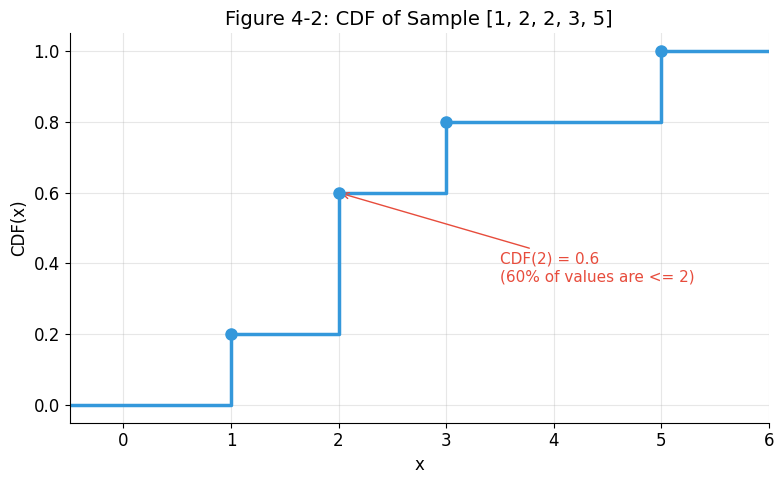

CDF step function plotted.


In [8]:
# Figure 4-2: CDF of the simple example [1, 2, 2, 3, 5]
fig, ax = plt.subplots(figsize=(8, 5))

# Plot the step function
xs_plot = np.concatenate([[-0.5], cdf_example.xs, [6]])
ps_plot = np.concatenate([[0], cdf_example.ps, [1]])

ax.step(xs_plot, ps_plot, where='post', color='#3498db', linewidth=2.5)

# Add dots at each data point
unique_xs = np.unique(cdf_example.xs)
for x in unique_xs:
    p = cdf_example.Prob(x)
    ax.plot(x, p, 'o', color='#3498db', markersize=8, zorder=5)

ax.set_xlabel('x')
ax.set_ylabel('CDF(x)')
ax.set_title('Figure 4-2: CDF of Sample [1, 2, 2, 3, 5]')
ax.set_xlim(-0.5, 6)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)

# Annotate
ax.annotate('CDF(2) = 0.6\n(60% of values are <= 2)',
            xy=(2, 0.6), xytext=(3.5, 0.35),
            arrowprops=dict(arrowstyle='->', color='#e74c3c'),
            fontsize=11, color='#e74c3c')

plt.tight_layout()
plt.show()
print("CDF step function plotted.")


The CDF is a **monotonically non-decreasing step function** that starts at 0 (below all data) and reaches 1 (at or above all data). Key features of the graph:

- **Vertical jumps** correspond to observed values. A value that appears multiple times (like $x = 2$ with two occurrences) produces a larger jump ($\Delta p = 2/5 = 0.4$).
- **Flat regions** indicate ranges with no data. Between $x = 3$ and $x = 5$, the CDF is flat at 0.8, meaning no observations fall in $(3, 5)$.
- **Steep regions** indicate where data is concentrated. If the CDF rises steeply, many values are packed into a narrow range.

This last property is why CDFs make distributional shape so clear: the **slope of the CDF** encodes the **density** of the distribution at each point.


## 4.6 CDF of Pregnancy Length


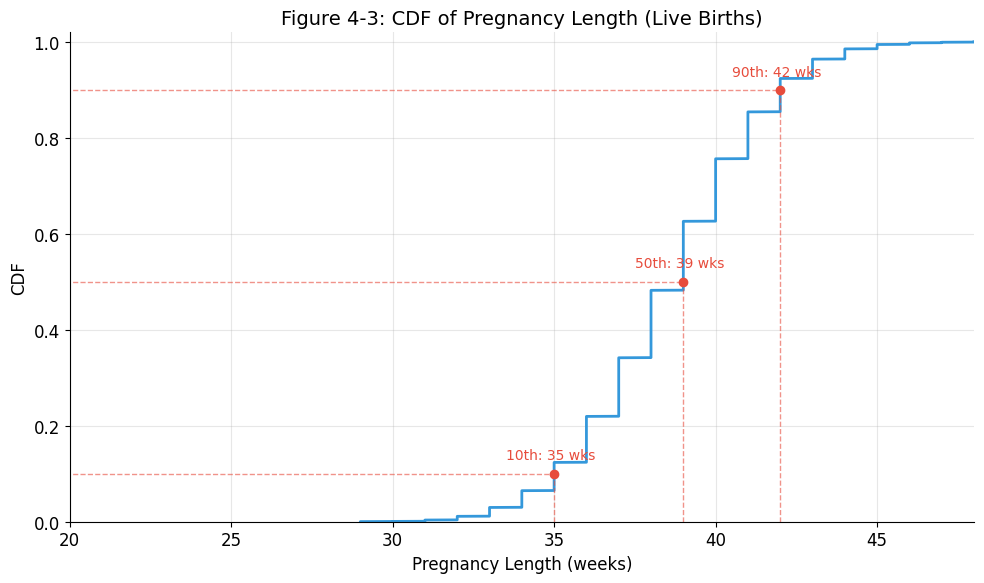

How to read a CDF -- key percentiles:
  10th percentile: 35 weeks
  25th percentile: 37 weeks
  50th percentile: 39 weeks
  75th percentile: 40 weeks
  90th percentile: 42 weeks


In [9]:
# Figure 4-3: CDF of pregnancy length for live births
cdf_prglngth = Cdf(live.prglngth, label='prglngth')

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(cdf_prglngth.xs, cdf_prglngth.ps, color='#3498db', linewidth=2)
ax.set_xlabel('Pregnancy Length (weeks)')
ax.set_ylabel('CDF')
ax.set_title('Figure 4-3: CDF of Pregnancy Length (Live Births)')
ax.grid(True, alpha=0.3)

# Annotate key percentiles
for pct in [10, 50, 90]:
    val = cdf_prglngth.Percentile(pct)
    prob = pct / 100
    ax.plot([val, val], [0, prob], '--', color='#e74c3c', alpha=0.6, linewidth=1)
    ax.plot([0, val], [prob, prob], '--', color='#e74c3c', alpha=0.6, linewidth=1)
    ax.plot(val, prob, 'o', color='#e74c3c', markersize=6)
    ax.text(val - 1.5, prob + 0.03, f'{pct}th: {val:.0f} wks', fontsize=10, color='#e74c3c')

ax.set_xlim(20, 48)
ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

print("How to read a CDF -- key percentiles:")
for p in [10, 25, 50, 75, 90]:
    print(f"  {p}th percentile: {cdf_prglngth.Percentile(p):.0f} weeks")


The textbook teaches how to **read** a CDF by looking up percentiles:

- About **10%** of pregnancies are shorter than 36 weeks (preterm)
- About **50%** (the median) fall at 39 weeks
- About **90%** are shorter than 41 weeks

The CDF also reveals distributional shape visually:

- The **steep section** around 37--41 weeks shows where data is concentrated (the full-term peak)
- The **flat region** below 30 weeks means very few values in that range (most pregnancies that short would not be live births)
- The **gradual flattening** above 41 weeks reflects the rarity of post-term pregnancies

Compared to the PMF, the CDF is **smooth** -- no spikes, no noise, no binning decisions. Every data point contributes to the curve in a well-defined way. The textbook's advice: "It takes some time to get used to CDFs, but once you do, I think you will find that they show more information, more clearly, than PMFs."


## 4.7 Comparing Distributions with CDFs


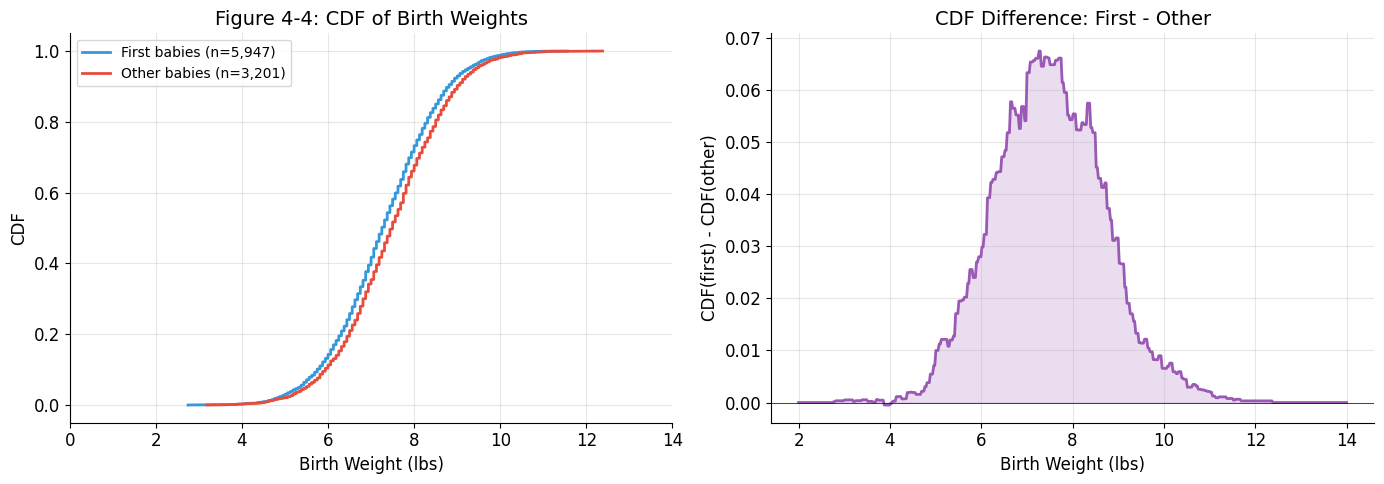

CDF comparison -- interpreting the gap:
  At 6 lbs: CDF(first)=0.143, CDF(other)=0.113
            -> 3.0 pp more first babies <= 6 lbs
  At 8 lbs: CDF(first)=0.733, CDF(other)=0.677
            -> 5.5 pp more first babies <= 8 lbs


In [10]:
# Figure 4-4: CDF of birth weights -- first babies vs. others
first_cdf = Cdf(firsts.totalwgt_lb.dropna(), label='First')
other_cdf = Cdf(others.totalwgt_lb.dropna(), label='Other')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: CDF comparison (Figure 4-4)
axes[0].plot(first_cdf.xs, first_cdf.ps, color='#3498db', linewidth=2,
             label=f'First babies (n={len(firsts):,})')
axes[0].plot(other_cdf.xs, other_cdf.ps, color='#e74c3c', linewidth=2,
             label=f'Other babies (n={len(others):,})')
axes[0].set_xlabel('Birth Weight (lbs)')
axes[0].set_ylabel('CDF')
axes[0].set_title('Figure 4-4: CDF of Birth Weights')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 14)

# Right: CDF difference (first_cdf - other_cdf)
common_xs = np.linspace(2, 14, 500)
first_interp = np.array([first_cdf.Prob(x) for x in common_xs])
other_interp = np.array([other_cdf.Prob(x) for x in common_xs])
cdf_diff = first_interp - other_interp

axes[1].plot(common_xs, cdf_diff, color='#9b59b6', linewidth=2)
axes[1].fill_between(common_xs, cdf_diff, 0, alpha=0.2, color='#9b59b6')
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].set_xlabel('Birth Weight (lbs)')
axes[1].set_ylabel('CDF(first) - CDF(other)')
axes[1].set_title('CDF Difference: First - Other')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("CDF comparison -- interpreting the gap:")
print(f"  At 6 lbs: CDF(first)={first_cdf.Prob(6):.3f}, CDF(other)={other_cdf.Prob(6):.3f}")
print(f"            -> {(first_cdf.Prob(6) - other_cdf.Prob(6))*100:.1f} pp more first babies <= 6 lbs")
print(f"  At 8 lbs: CDF(first)={first_cdf.Prob(8):.3f}, CDF(other)={other_cdf.Prob(8):.3f}")
print(f"            -> {(first_cdf.Prob(8) - other_cdf.Prob(8))*100:.1f} pp more first babies <= 8 lbs")


Compared to the noisy PMF in Figure 4-1, the CDF comparison (reproducing Figure 4-4) makes the pattern **immediately clear**: the first-babies curve lies **consistently to the left** of (and above) the others curve. This means that at every weight threshold, a larger fraction of first babies fall below it -- first babies are **lighter throughout the entire distribution**, not just at the mean.

How to read a CDF comparison:
- If curve A is **above** curve B at value $x$, then $P(A \le x) > P(B \le x)$ -- group A has more low values
- If curve A is **to the left** of curve B, group A's values tend to be smaller
- The **horizontal distance** between the curves at any probability level shows how much the distributions differ in that region

The right panel shows the CDF difference ($\text{CDF}_{\text{first}} - \text{CDF}_{\text{other}}$). A positive difference means the first-baby CDF is above the other-baby CDF -- first babies have accumulated more probability mass at that weight. The difference is largest above the mean ($\sim 7$--$9$ lbs), confirming the textbook's observation of "a larger discrepancy above the mean."


## 4.8 Percentile-Based Summary Statistics

Once you have a CDF, computing percentile-based statistics is trivial. These are often more informative than moment-based statistics (mean, variance) because they are **robust to outliers** and provide direct interpretations.


In [11]:
# Percentile-based statistics for birth weight
wgt_cdf = Cdf(live.totalwgt_lb.dropna(), label='totalwgt_lb')

median = wgt_cdf.Percentile(50)
q25 = wgt_cdf.Percentile(25)
q75 = wgt_cdf.Percentile(75)
iqr = q75 - q25

print("Birth weight -- percentile-based statistics:")
print(f"  Minimum:  {wgt_cdf.xs[0]:.2f} lbs")
print(f"  25th pct: {q25:.2f} lbs")
print(f"  Median:   {median:.2f} lbs")
print(f"  75th pct: {q75:.2f} lbs")
print(f"  Maximum:  {wgt_cdf.xs[-1]:.2f} lbs")
print(f"  IQR:      {iqr:.2f} lbs")
print(f"\n  Mean:     {live.totalwgt_lb.mean():.2f} lbs")
print(f"  Std:      {live.totalwgt_lb.std():.2f} lbs")

print(f"\nQuintiles (20th, 40th, 60th, 80th):")
for p in [20, 40, 60, 80]:
    print(f"  {p}th percentile: {wgt_cdf.Percentile(p):.2f} lbs")

print(f"\nDeciles (10th through 90th):")
for p in range(10, 100, 10):
    print(f"  {p}th percentile: {wgt_cdf.Percentile(p):.2f} lbs")


Birth weight -- percentile-based statistics:
  Minimum:  2.75 lbs
  25th pct: 6.56 lbs
  Median:   7.31 lbs
  75th pct: 8.19 lbs
  Maximum:  12.38 lbs
  IQR:      1.62 lbs

  Mean:     7.36 lbs
  Std:      1.20 lbs

Quintiles (20th, 40th, 60th, 80th):
  20th percentile: 6.38 lbs
  40th percentile: 7.06 lbs
  60th percentile: 7.69 lbs
  80th percentile: 8.38 lbs

Deciles (10th through 90th):
  10th percentile: 5.81 lbs
  20th percentile: 6.38 lbs
  30th percentile: 6.75 lbs
  40th percentile: 7.06 lbs
  50th percentile: 7.31 lbs
  60th percentile: 7.69 lbs
  70th percentile: 8.00 lbs
  80th percentile: 8.38 lbs
  90th percentile: 8.88 lbs


Key percentile-based statistics:

| Statistic | Definition | Interpretation |
|-----------|-----------|----------------|
| **Median** (50th percentile) | $\text{CDF}^{-1}(0.5)$ | Central value; half the data is above, half below |
| **IQR** (interquartile range) | $Q_3 - Q_1 = P_{75} - P_{25}$ | Spread of the middle 50% of data |
| **Quintiles** | $P_{20}, P_{40}, P_{60}, P_{80}$ | Divide data into 5 equal groups (common for income) |
| **Deciles** | $P_{10}, P_{20}, \ldots, P_{90}$ | Divide data into 10 equal groups |

More generally, any set of equally spaced CDF values are called **quantiles**. Quantiles provide a complete, nonparametric summary of the distribution's shape without assuming any functional form (like normality).

The IQR is particularly useful as a measure of spread because it ignores outliers entirely -- only the middle 50% of data matters. Compare this to the standard deviation, which is heavily influenced by extreme values because it involves squaring deviations.


## 4.9 The Uniform Distribution of Percentile Ranks

Here is a beautiful result that connects CDFs to random number generation. If we take a random sample from any distribution, compute the percentile rank of each value, and plot the CDF of those ranks, we get a **straight line** -- the ranks are uniformly distributed, regardless of the original distribution's shape.

Why? By definition, $p\%$ of the data falls at or below the $p$-th percentile. So $10\%$ of values have ranks $\le 10$, $20\%$ have ranks $\le 20$, and so on -- exactly the definition of a uniform distribution.


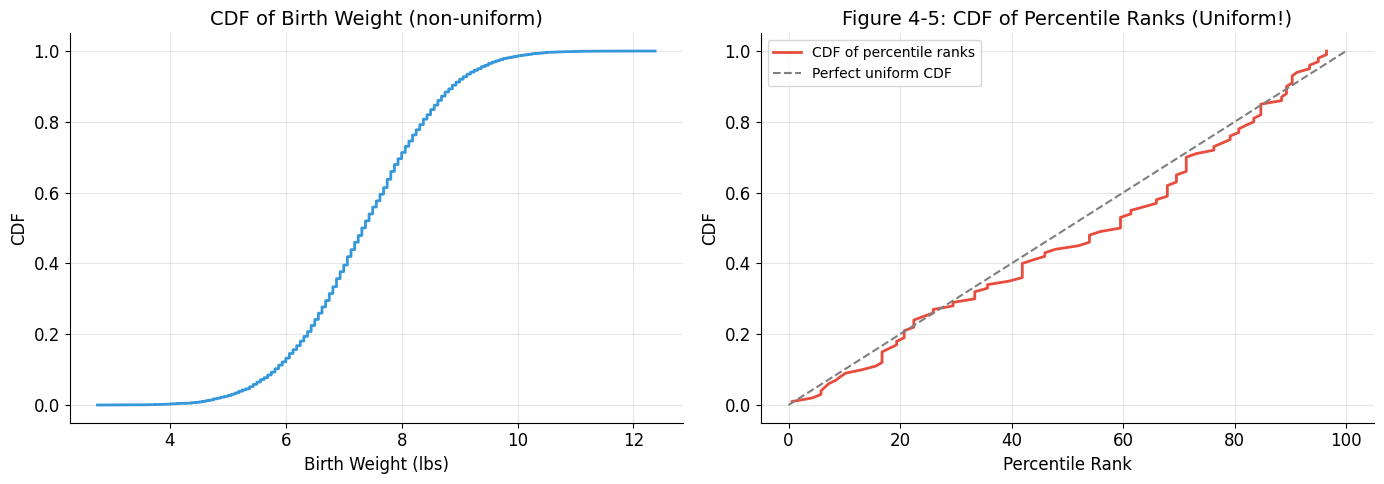

The CDF of percentile ranks is approximately a straight line (uniform).
This holds regardless of the original distribution's shape.


In [12]:
# Demonstrate: CDF of percentile ranks is uniform
np.random.seed(17)
weights = live.totalwgt_lb.dropna().values
cdf_wgt = Cdf(weights, label='birth weight')

# Random sample and compute percentile ranks
sample = np.random.choice(weights, 100, replace=True)
ranks = [cdf_wgt.PercentileRank(x) for x in sample]

# CDF of the ranks
rank_cdf = Cdf(ranks, label='percentile ranks')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: CDF of the original data (non-uniform shape)
axes[0].plot(cdf_wgt.xs, cdf_wgt.ps, color='#3498db', linewidth=2)
axes[0].set_xlabel('Birth Weight (lbs)')
axes[0].set_ylabel('CDF')
axes[0].set_title('CDF of Birth Weight (non-uniform)')
axes[0].grid(True, alpha=0.3)

# Right: CDF of percentile ranks (approximately uniform = straight line)
axes[1].plot(rank_cdf.xs, rank_cdf.ps, color='#e74c3c', linewidth=2,
             label='CDF of percentile ranks')
axes[1].plot([0, 100], [0, 1], '--', color='gray', linewidth=1.5,
             label='Perfect uniform CDF')
axes[1].set_xlabel('Percentile Rank')
axes[1].set_ylabel('CDF')
axes[1].set_title('Figure 4-5: CDF of Percentile Ranks (Uniform!)')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("The CDF of percentile ranks is approximately a straight line (uniform).")
print("This holds regardless of the original distribution's shape.")


Figure 4-5 confirms the result: the CDF of percentile ranks hugs the diagonal (the CDF of a uniform distribution). Deviations from the line are due to finite sample size; with more data, the match would be even closer.

This result -- that $\text{CDF}(X)$ is uniformly distributed when $X$ is drawn from the distribution -- is formally known as the **probability integral transform**. It is one of the most useful results in computational statistics because it gives us a recipe for generating random numbers from *any* distribution:

**Inverse CDF Algorithm:**
1. Generate $u \sim \text{Uniform}(0, 1)$
2. Compute $x = \text{CDF}^{-1}(u)$
3. The resulting $x$ follows the target distribution

This is exactly what our `Cdf.Random()` method does: it calls `random.random()` to get $u$, then calls `self.Value(u)` (the inverse CDF) to get $x$.


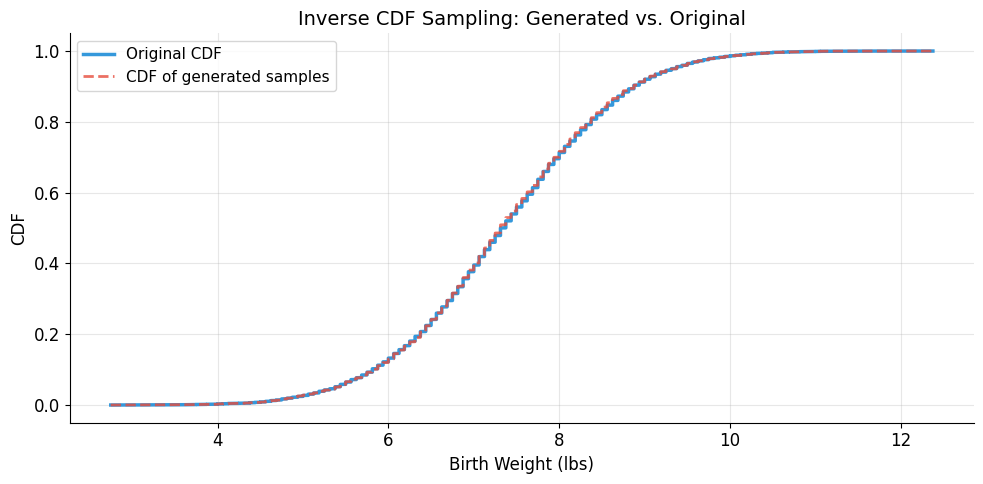

The generated samples match the original distribution.
  Original mean:  7.358
  Generated mean: 7.347
  Original std:   1.200
  Generated std:  1.195


In [13]:
# Demonstrate inverse CDF random generation
np.random.seed(42)

# Generate 10,000 random birth weights using inverse CDF
cdf_wgt = Cdf(weights, label='birth weight')
generated = [cdf_wgt.Random() for _ in range(10_000)]
generated_cdf = Cdf(generated, label='Generated')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cdf_wgt.xs, cdf_wgt.ps, color='#3498db', linewidth=2.5,
        label='Original CDF')
ax.plot(generated_cdf.xs, generated_cdf.ps, '--', color='#e74c3c',
        linewidth=2, alpha=0.8, label='CDF of generated samples')
ax.set_xlabel('Birth Weight (lbs)')
ax.set_ylabel('CDF')
ax.set_title('Inverse CDF Sampling: Generated vs. Original')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("The generated samples match the original distribution.")
print(f"  Original mean:  {np.mean(weights):.3f}")
print(f"  Generated mean: {np.mean(generated):.3f}")
print(f"  Original std:   {np.std(weights):.3f}")
print(f"  Generated std:  {np.std(generated):.3f}")


The generated samples reproduce the original distribution faithfully -- the CDFs are nearly indistinguishable. The inverse CDF method is a general-purpose random number generator that works for any empirical or theoretical distribution, as long as we can evaluate the inverse CDF.

In practice, you would typically use NumPy's built-in generators (`np.random.normal`, `np.random.choice`, etc.) for standard distributions, but the inverse CDF method is invaluable when you need to sample from a custom empirical distribution or a theoretical distribution without a built-in generator.


## 4.10 Comparing Percentile Ranks Across Groups

Percentile ranks are powerful for comparing measurements across **different groups** where the raw values are not directly comparable. The textbook illustrates this with a foot race example.

When runners are grouped by age, raw finishing times are not comparable across groups (older runners are naturally slower). But **percentile rank within your age group** provides a meaningful cross-group comparison: a 90th-percentile performance in the M4049 division is "equivalent" to a 90th-percentile performance in M5059, even though the actual times differ.


In [14]:
# 10K race example from textbook
def PositionToPercentile(position, field_size):
    beat = field_size - position + 1
    return 100.0 * beat / field_size

def PercentileToPosition(percentile, field_size):
    beat = percentile * field_size / 100.0
    return field_size - beat + 1

# Textbook's James Joyce Ramble 10K data
finish_time = "42:44"
overall_position = 97
overall_field = 1633
age_position = 26
age_field = 256      # M4049
future_field = 171   # M5059

overall_pct = PositionToPercentile(overall_position, overall_field)
age_pct = PositionToPercentile(age_position, age_field)
future_position = PercentileToPosition(age_pct, future_field)

print("James Joyce Ramble 10K -- Percentile Rank Analysis")
print("=" * 55)
print(f"  Finish time:     {finish_time}")
print(f"  Overall:         {overall_position}th of {overall_field} -> {overall_pct:.1f}th percentile")
print(f"  M4049 division:  {age_position}th of {age_field} -> {age_pct:.1f}th percentile")
print(f"\n  Projection to M5059 ({future_field} runners):")
print(f"    To maintain {age_pct:.1f}th percentile:")
print(f"    Need position: {future_position:.1f}")
print(f"    (The 17th-place M5059 finisher ran 46:05)")
print(f"\n  Expected slowdown: 42:44 -> 46:05 = {46*60+5 - 42*60-44:.0f} seconds ({(46*60+5)/(42*60+44)*100-100:.1f}%)")


James Joyce Ramble 10K -- Percentile Rank Analysis
  Finish time:     42:44
  Overall:         97th of 1633 -> 94.1th percentile
  M4049 division:  26th of 256 -> 90.2th percentile

  Projection to M5059 (171 runners):
    To maintain 90.2th percentile:
    Need position: 17.7
    (The 17th-place M5059 finisher ran 46:05)

  Expected slowdown: 42:44 -> 46:05 = 201 seconds (7.8%)


The percentile rank provides a **portable measure of performance** that adjusts for the characteristics of each comparison group. The textbook's author finished in the 94th percentile overall and 90th percentile in his age group. To maintain that 90th percentile in the next age division (M5059), he would need to finish around 17th--18th place, corresponding to a time of 46:05.

This technique applies far beyond running:
- Comparing student test scores across different schools or years
- Comparing salaries across different industries or cities
- Comparing health metrics across different age groups
- Any situation where raw values are not directly comparable but relative standing is meaningful

The key principle: **percentile ranks are invariant to monotonic transformations** of the underlying data. Whether you measure time in seconds or minutes, the percentile ranks are the same. This makes them robust, interpretable, and universally comparable.


## 4.11 Exercises


### Exercise 4-1: Your Birth Weight Percentile


Birth Weight Percentile Lookup Table
  Weight   All births   First babies   Other babies
------------------------------------------------------------
     5.0         2.7%           3.1%           2.1%
     5.5         6.5%           7.2%           5.2%
     6.0        13.2%          14.3%          11.3%
     6.5        24.2%          25.9%          21.0%
     7.0        39.5%          41.8%          35.4%
     7.5        55.9%          58.2%          51.7%
     8.0        71.3%          73.3%          67.7%
     8.5        83.4%          85.0%          80.5%
     9.0        92.0%          93.0%          90.3%
     9.5        96.5%          96.9%          95.8%
    10.0        98.6%          98.9%          98.2%

The textbook says: if you are in the 90th percentile or higher,
call your mother back and apologize!


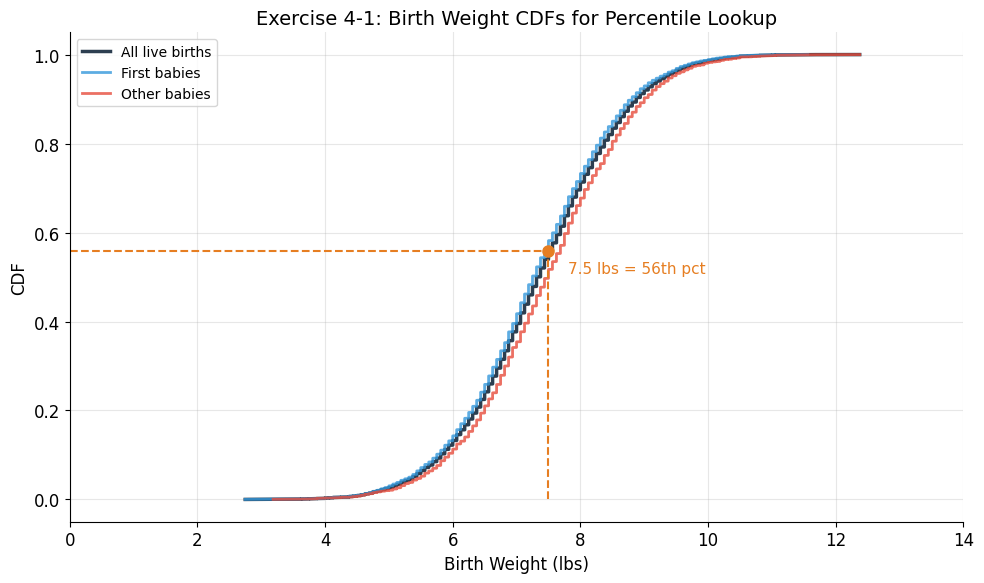

Birth weight CDFs plotted with percentile lookup example.


In [15]:
# Exercise 4-1: Birth weight percentile lookup
all_cdf = Cdf(live.totalwgt_lb.dropna(), label='All live births')
first_cdf_wgt = Cdf(firsts.totalwgt_lb.dropna(), label='First babies')
other_cdf_wgt = Cdf(others.totalwgt_lb.dropna(), label='Other babies')

# Example: lookup for various birth weights
print("Birth Weight Percentile Lookup Table")
print("=" * 60)
print(f"{'Weight':>8} {'All births':>12} {'First babies':>14} {'Other babies':>14}")
print("-" * 60)
for wgt in [5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]:
    pct_all = all_cdf.PercentileRank(wgt)
    pct_first = first_cdf_wgt.PercentileRank(wgt)
    pct_other = other_cdf_wgt.PercentileRank(wgt)
    marker = " <-- 90th pct!" if 89 <= pct_all <= 91 else ""
    print(f"{wgt:8.1f} {pct_all:11.1f}% {pct_first:13.1f}% {pct_other:13.1f}%{marker}")

print(f"\nThe textbook says: if you are in the 90th percentile or higher,")
print(f"call your mother back and apologize!")

# Visualize the lookup process
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(all_cdf.xs, all_cdf.ps, color='#2c3e50', linewidth=2.5, label='All live births')
ax.plot(first_cdf_wgt.xs, first_cdf_wgt.ps, color='#3498db', linewidth=2, alpha=0.8,
        label='First babies')
ax.plot(other_cdf_wgt.xs, other_cdf_wgt.ps, color='#e74c3c', linewidth=2, alpha=0.8,
        label='Other babies')
ax.set_xlabel('Birth Weight (lbs)')
ax.set_ylabel('CDF')
ax.set_title('Exercise 4-1: Birth Weight CDFs for Percentile Lookup')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 14)

# Example annotation for 7.5 lbs
ex_wgt = 7.5
ex_pct = all_cdf.Prob(ex_wgt)
ax.plot([ex_wgt, ex_wgt], [0, ex_pct], '--', color='#e67e22', linewidth=1.5)
ax.plot([0, ex_wgt], [ex_pct, ex_pct], '--', color='#e67e22', linewidth=1.5)
ax.plot(ex_wgt, ex_pct, 'o', color='#e67e22', markersize=8)
ax.text(ex_wgt + 0.3, ex_pct - 0.05, f'{ex_wgt} lbs = {ex_pct*100:.0f}th pct',
        fontsize=11, color='#e67e22')

plt.tight_layout()
plt.show()
print("Birth weight CDFs plotted with percentile lookup example.")


The lookup table shows percentile ranks for various birth weights across all live births, first babies only, and other babies. Notice that the same weight corresponds to a **higher percentile rank** in the first-baby distribution (because first babies are lighter on average) -- a 7.5-lb first baby is more impressive (relative to peers) than a 7.5-lb subsequent baby.

This is another practical application of CDFs: converting raw measurements into meaningful percentile ranks that account for the distribution of the comparison group.


### Exercise 4-2: Testing Uniformity of `random.random`


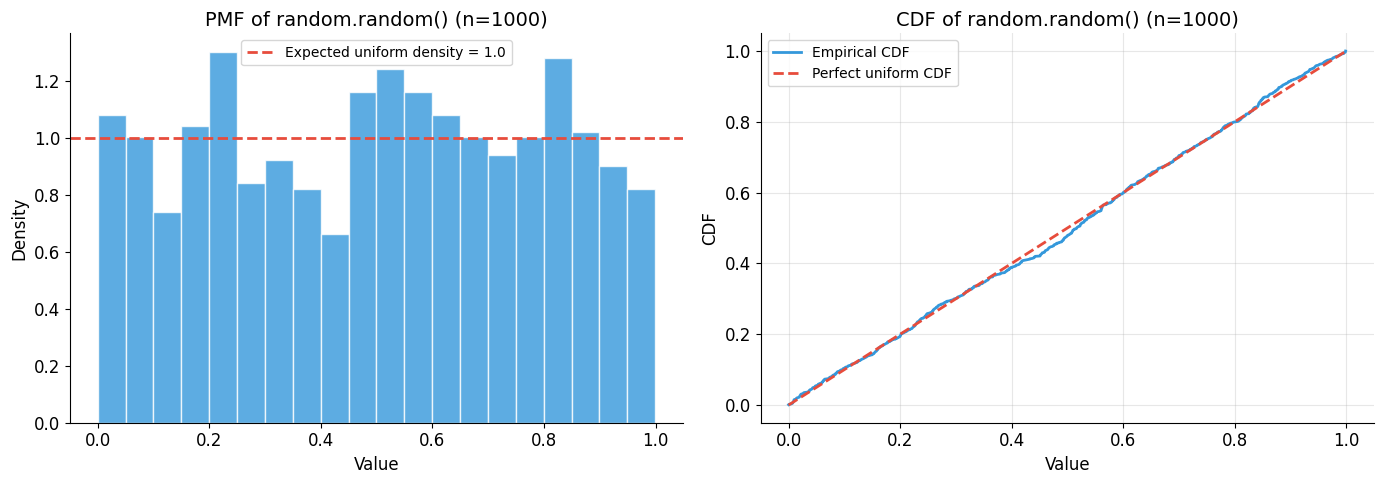

Kolmogorov-Smirnov test for uniformity:
  Statistic: 0.0311
  p-value:   0.2835
  Conclusion: Consistent with uniform (at alpha=0.05)


In [16]:
# Exercise 4-2: Is random.random truly uniform?
np.random.seed(42)
uniform_sample = [random.random() for _ in range(1000)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PMF (noisy but roughly flat)
axes[0].hist(uniform_sample, bins=20, density=True, color='#3498db',
             edgecolor='white', alpha=0.8)
axes[0].axhline(y=1.0, color='#e74c3c', linestyle='--', linewidth=2,
                label='Expected uniform density = 1.0')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].set_title('PMF of random.random() (n=1000)')
axes[0].legend(fontsize=10)

# Right: CDF (should be a straight line)
uni_cdf = Cdf(uniform_sample, label='random.random()')
axes[1].plot(uni_cdf.xs, uni_cdf.ps, color='#3498db', linewidth=2,
             label='Empirical CDF')
axes[1].plot([0, 1], [0, 1], '--', color='#e74c3c', linewidth=2,
             label='Perfect uniform CDF')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('CDF')
axes[1].set_title('CDF of random.random() (n=1000)')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Kolmogorov-Smirnov test for uniformity
from scipy.stats import kstest
stat, pval = kstest(uniform_sample, 'uniform')
print(f"Kolmogorov-Smirnov test for uniformity:")
print(f"  Statistic: {stat:.4f}")
print(f"  p-value:   {pval:.4f}")
print(f"  Conclusion: {'Consistent with uniform' if pval > 0.05 else 'NOT uniform'} (at alpha=0.05)")


This exercise illustrates the CDF's diagnostic power. The PMF (histogram, left panel) shows the expected roughly flat pattern but is noisy -- individual bin heights fluctuate visibly. The CDF (right panel) provides a much cleaner assessment: it hugs the diagonal $y = x$ closely, confirming uniformity.

The **Kolmogorov-Smirnov (KS) test** formalizes this comparison. It measures the maximum vertical distance between the empirical CDF and the theoretical CDF of the hypothesized distribution (here, $\text{Uniform}(0, 1)$). A large $p$-value means the data is consistent with uniformity -- exactly what we expect from a well-implemented random number generator.

This exercise also demonstrates a general diagnostic technique: to check whether data follows any hypothesized distribution, plot the empirical CDF against the theoretical CDF and look for systematic deviations.


## 4.12 Key Concepts and Terminology

| Term | Definition | Key relationship |
|------|-----------|-----------------|
| **CDF** | $\text{CDF}(x) = P(X \le x)$ | Maps values $\to$ cumulative probabilities |
| **Inverse CDF** | $\text{CDF}^{-1}(p) = x$ | Maps probabilities $\to$ values |
| **Percentile rank** | $100 \cdot \text{CDF}(x)$ | CDF expressed as a percentage |
| **Percentile** | $\text{CDF}^{-1}(p/100)$ | Value at a given percentile rank |
| **Median** | 50th percentile | Central value; robust to outliers |
| **IQR** | $P_{75} - P_{25}$ | Spread of the middle 50% |
| **Quantiles** | Equally spaced CDF values | Quintiles (5), deciles (10), percentiles (100) |
| **Prob. integral transform** | $\text{CDF}(X) \sim \text{Uniform}(0, 1)$ | Basis for inverse CDF sampling |

**The CDF advantage over PMFs:**

| Property | PMF | CDF |
|----------|-----|-----|
| Noise with many values | High (each probability is tiny) | None (monotonically smooth) |
| Comparing distributions | Hard (sample size distortion) | Easy (curves on same scale) |
| Binning required? | Effectively yes, for continuous data | No |
| Percentile computation | Requires sorting | Built-in (inverse CDF) |
| Random number generation | Clumsy | Elegant (inverse CDF method) |

**Looking ahead.** Chapter 5 models distributions with **analytical functions** -- the exponential, normal, lognormal, and Pareto distributions. We will use CDF plots to test whether empirical data matches these theoretical models, a technique that leverages everything we have learned in this chapter.


---

## Appendix: Book's Original Code

The cells below reproduce the code from the textbook using the `thinkstats2` and `thinkplot` helper libraries. These cells require the ThinkStats2 helper modules downloaded in Section 4.2 and are designed to run on Google Colab.


### A.1 The Noisy PMF Problem (Figure 4-1)


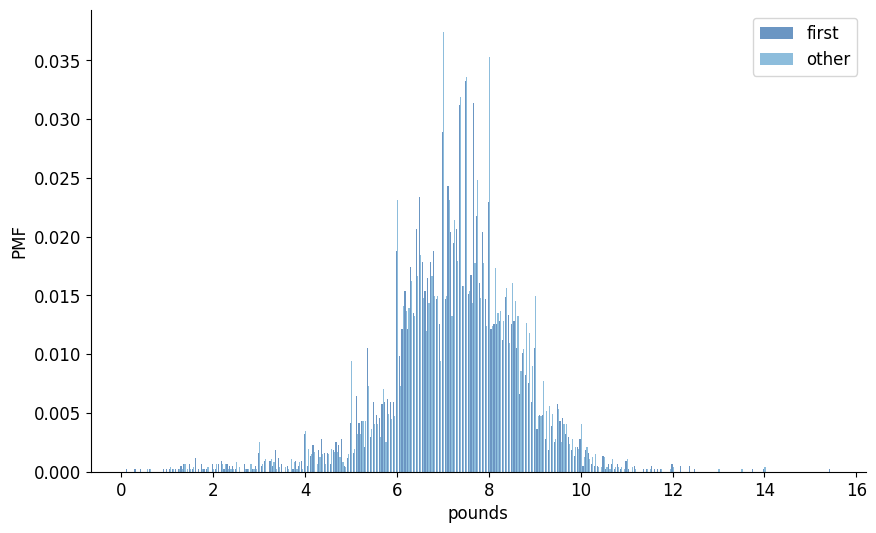

<Figure size 800x600 with 0 Axes>

In [17]:
# Book's original code: PMF of birth weights (Figure 4-1)
# Requires: thinkstats2.py, thinkplot.py, first.py

import first
import thinkstats2
import thinkplot

live, firsts, others = first.MakeFrames()

first_pmf = thinkstats2.Pmf(firsts.totalwgt_lb, label='first')
other_pmf = thinkstats2.Pmf(others.totalwgt_lb, label='other')

width = 0.4 / 16.0  # narrow bars for fine-grained data
thinkplot.PrePlot(2)
thinkplot.Hist(first_pmf, align='right', width=width)
thinkplot.Hist(other_pmf, align='left', width=width)
thinkplot.Show(xlabel='pounds', ylabel='PMF')


The textbook uses `first.MakeFrames()` to load the NSFG data and split it into live births, first babies, and others. The PMF of `totalwgt_lb` produces the noisy Figure 4-1 that motivates the switch to CDFs.


### A.2 Creating and Using CDF Objects


In [18]:
# Book's original code: Cdf creation and basic operations
# Requires: thinkstats2.py, first.py

import first
import thinkstats2

live, firsts, others = first.MakeFrames()

cdf = thinkstats2.Cdf(live.prglngth, label='prglngth')

# Forward CDF: value -> probability
print("CDF(39):", cdf.Prob(39))       # P(X <= 39)
print("CDF[39]:", cdf[39])            # bracket operator equivalent

# Inverse CDF: probability -> value
print("Value(0.5):", cdf.Value(0.5))  # median

# Percentile methods
print("PercentileRank(39):", cdf.PercentileRank(39))
print("Percentile(50):", cdf.Percentile(50))


CDF(39): 0.7544818539571491
CDF[39]: 0.7544818539571491
Value(0.5): 39
PercentileRank(39): 75.4481853957149
Percentile(50): 39


The `thinkstats2.Cdf` class provides `Prob(x)` for the forward CDF and `Value(p)` for the inverse CDF. `PercentileRank` and `Percentile` are convenience wrappers that convert between probabilities (0--1) and percentages (0--100).


### A.3 Plotting CDFs (Figures 4-3 and 4-4)


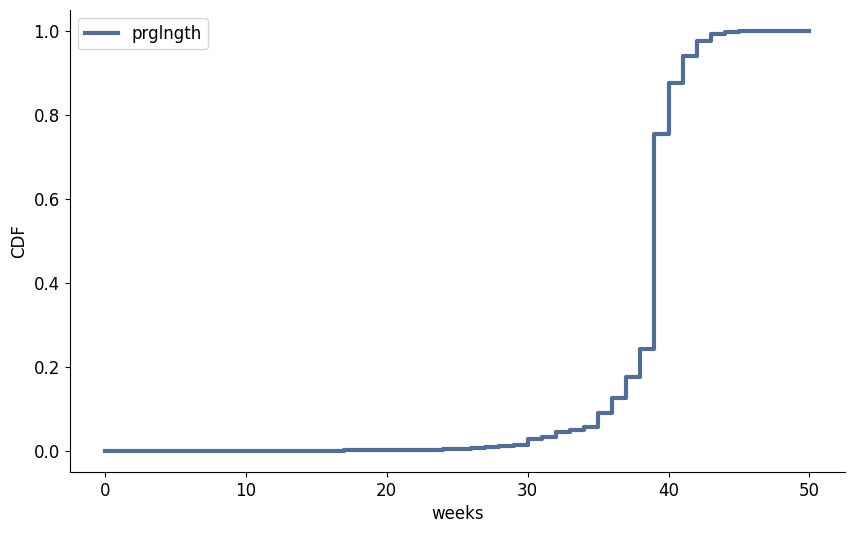

<Figure size 800x600 with 0 Axes>

In [19]:
# Book's original code: CDF of pregnancy length (Figure 4-3)
# Requires: thinkstats2.py, thinkplot.py, first.py

import first
import thinkstats2
import thinkplot

live, firsts, others = first.MakeFrames()

cdf = thinkstats2.Cdf(live.prglngth, label='prglngth')
thinkplot.Cdf(cdf)
thinkplot.Show(xlabel='weeks', ylabel='CDF')


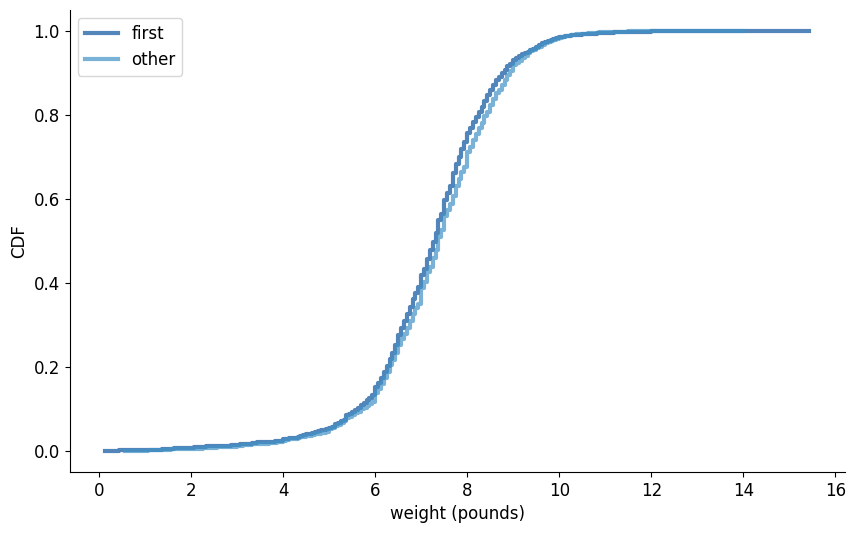

<Figure size 800x600 with 0 Axes>

In [20]:
# Book's original code: CDF comparison of birth weights (Figure 4-4)
# Requires: thinkstats2.py, thinkplot.py, first.py

import first
import thinkstats2
import thinkplot

live, firsts, others = first.MakeFrames()

first_cdf = thinkstats2.Cdf(firsts.totalwgt_lb, label='first')
other_cdf = thinkstats2.Cdf(others.totalwgt_lb, label='other')

thinkplot.PrePlot(2)
thinkplot.Cdfs([first_cdf, other_cdf])
thinkplot.Show(xlabel='weight (pounds)', ylabel='CDF')


`thinkplot.Cdf()` plots a single CDF as a line. `thinkplot.Cdfs()` accepts a list of CDF objects and plots them on the same axes, using `PrePlot(2)` to set up a two-color palette. The result is Figure 4-4, showing first babies consistently lighter than others.


### A.4 Random Number Generation via Inverse CDF (Figure 4-5)


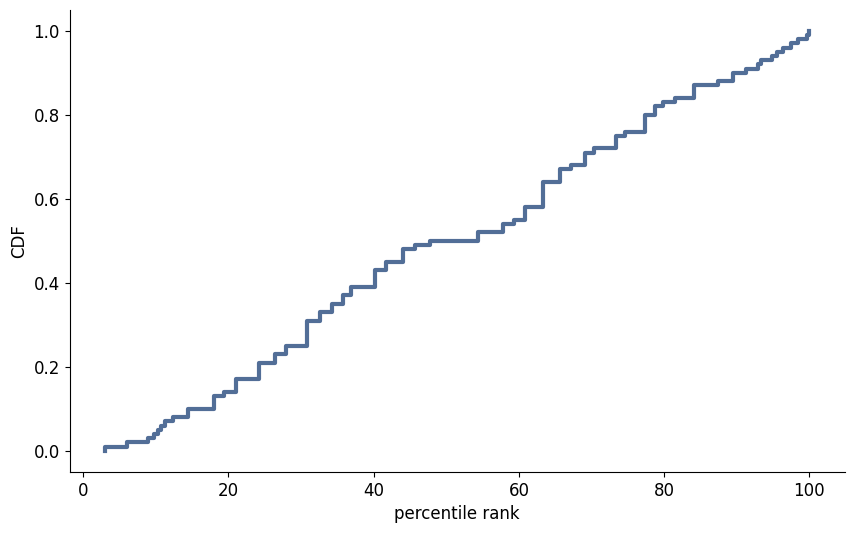

<Figure size 800x600 with 0 Axes>

In [21]:
# Book's original code: CDF of percentile ranks (Figure 4-5)
# Requires: thinkstats2.py, thinkplot.py, first.py

import numpy as np
import first
import thinkstats2
import thinkplot

live, firsts, others = first.MakeFrames()

weights = live.totalwgt_lb
cdf = thinkstats2.Cdf(weights, label='totalwgt_lb')

sample = np.random.choice(weights, 100, replace=True)
ranks = [cdf.PercentileRank(x) for x in sample]

rank_cdf = thinkstats2.Cdf(ranks)
thinkplot.Cdf(rank_cdf)
thinkplot.Show(xlabel='percentile rank', ylabel='CDF')


The CDF of percentile ranks is approximately a straight line from (0, 0) to (100, 1), confirming that percentile ranks are uniformly distributed regardless of the underlying data distribution. The textbook uses this result to motivate the inverse CDF sampling algorithm implemented as `Cdf.Random()`.


### A.5 Comparing Percentile Ranks Across Groups


In [22]:
# Book's original code: 10K race percentile comparison

def PositionToPercentile(position, field_size):
    beat = field_size - position + 1
    percentile = 100.0 * beat / field_size
    return percentile

def PercentileToPosition(percentile, field_size):
    beat = percentile * field_size / 100.0
    position = field_size - beat + 1
    return position

# Author's results from James Joyce Ramble 10K
# Overall: 97th out of 1633 -> 94th percentile
print("Overall percentile:", PositionToPercentile(97, 1633))

# M4049: 26th out of 256 -> 90th percentile
print("M4049 percentile:", PositionToPercentile(26, 256))

# Projection to M5059 (171 runners):
print("Position needed in M5059:", PercentileToPosition(90.234375, 171))
# -> between 17th and 18th place; 17th place ran 46:05


Overall percentile: 94.12124923453766
M4049 percentile: 90.234375
Position needed in M5059: 17.69921875


The textbook demonstrates converting between positions and percentile ranks to compare performance across age groups. The 90th-percentile performance in M4049 (26th of 256) corresponds to roughly 17th place in M5059 (171 runners), projecting a slowdown from 42:44 to 46:05 over ten years.

---

*End of Appendix. The code above is provided for reference and requires the ThinkStats2 helper modules to execute. All substantive analysis in the main notebook uses standard Python libraries (pandas, NumPy, matplotlib, scipy) that produce equivalent results.*
